In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy as sp
from scipy import constants
from scipy.sparse.linalg import eigsh
from scipy.integrate import quad
from matplotlib.ticker import (MultipleLocator, AutoMinorLocator)
%matplotlib inline 

In [ ]:
def A_func(v, A0, a0, b0):
    return v*sp.special.jv(0,A0*b0)

def B_func(w, A0, a0, b0):
    return w*sp.special.jv(0,A0*(a0-b0))

def winding_number(v, w, c, A0, a0, b0, n):
    A = A_func(v,A0, a0, b0)
    B = B_func(w,A0, a0, b0)
    vi = 0
    for k in np.linspace(-np.pi, np.pi, n):
        P1 = (b0*A*np.cos(k*b0) - (a0-b0)*B*np.cos(k*(a0-b0)))/(B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c)
        P2 = (A*np.sin(k*b0) - B*np.sin(k*(a0-b0)))*(-(a0-b0)*B*np.sin(k*(a0-b0)) - b0*A*np.sin(k*b0))/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
        P3 = np.power((A*np.sin(k*b0) - B*np.sin(k*(a0-b0))),2)/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
        vi += (P1-P2)*(2*np.pi/n)/(P3+1)
    return vi/(2*np.pi)

def winding_number2(v,w,c,A0,a0,b0,n):
    A = A_func(v,A0, a0, b0)
    B = B_func(w,A0, a0, b0)
    vi = 0
    for k in np.linspace(-np.pi, np.pi, n):
        equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
        dequis = -A*b0*np.sin(k*b0) - B*(a0 - b0)*np.sin(k*(a0 - b0))
        ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
        dye = A*b0*np.cos(k*b0) - B*(a0 - b0)*np.cos(k*(a0 - b0))
        vi += (equis*dye - ye*dequis )*(2*np.pi/n)/(np.power(equis,2) + np.power(ye,2))
    return vi/(2*np.pi)

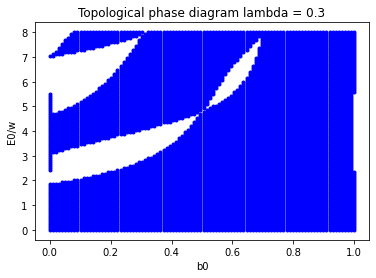

In [ ]:
fig, ax = plt.subplots()
lambda1 = 0.3
for b0 in np.linspace(0,1,100):
    for A0 in np.linspace(0,8,100):
        v2 = winding_number(0.3,1,0,A0,1,b0,100)
        if (v2 < 0.0):
            ax.plot(b0,A0,'b.')
ax.set_title('Topological phase diagram lambda = 0.3')
ax.set(xlabel='b0', ylabel='E0/w')
plt.show()

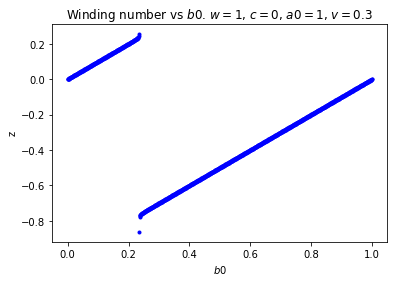

In [ ]:
fig, ax = plt.subplots()
E0 = 2.5
v = 0.3
w = 1
c = 0
a0 = 1
for b0 in np.linspace(0,1,1000):
  z = winding_number(v,w,c,E0,a0,b0,10000)
  ax.plot(b0,z,'b.')
ax.set_title(r'Winding number vs $b0$. ' + r'$w = {}$, $c = {}$, $a0 = {}$, $v = {}$'.format(w,c,a0, v))
ax.set(xlabel=r'$b0$', ylabel='z')
plt.show()

In [ ]:
winding_number(0.3,1,0,0,1,0,1000)

-1.000428571428571

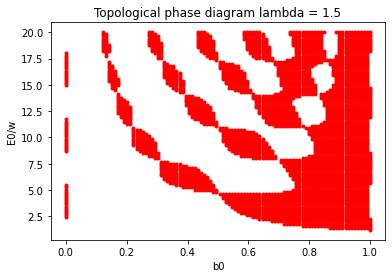

In [ ]:
fig, ax = plt.subplots()
lambda1 = 0.3
for b0 in np.linspace(0,1,100):
    for A0 in np.linspace(0,20,100):
        v2 = winding_number(1.5,1,0,A0,1,b0,100)
        if (v2 < -0.0):
            ax.plot(b0,A0,'r.')
ax.set_title('Topological phase diagram lambda = 1.5')
ax.set(xlabel='b0', ylabel='E0/w')
plt.show()

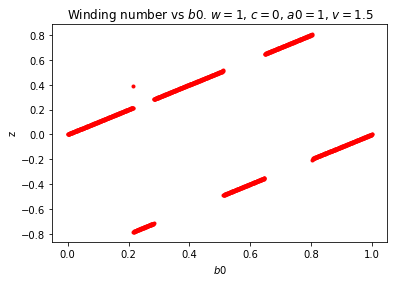

In [ ]:
fig, ax = plt.subplots()
E0 = 10
v = 1.5
w = 1
c = 0
a0 = 1
for b0 in np.linspace(0,1,1000):
  z = winding_number(v,w,c,E0,a0,b0,10000)
  ax.plot(b0,z,'r.')
ax.set_title(r'Winding number vs $b0$. ' + r'$w = {}$, $c = {}$, $a0 = {}$, $v = {}$'.format(w,c,a0, v))
ax.set(xlabel=r'$b0$', ylabel='z')
plt.show()

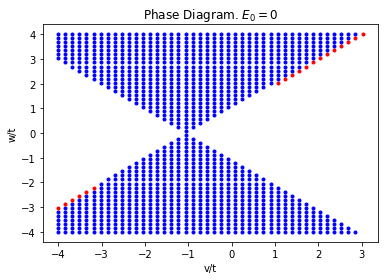

In [ ]:
fig, ax = plt.subplots()
E0 = 0
for v in np.linspace(-4, 4, 50):
    for w in np.linspace(-4, 4, 50):
        z = winding_number2(v,w,1,E0,1,0,1000)
        if (z > -1.1 and z < -0.9):
            ax.plot(v,w,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(v,w,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(v,w,'g.')
        elif(z == 'nan'):
            ax.plot(v,w,'k.')
        else:
            ax.plot(v,w,'r.')
ax.set_title('Phase Diagram. ' + r'$E_0 = {}$'.format(E0))
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.show()

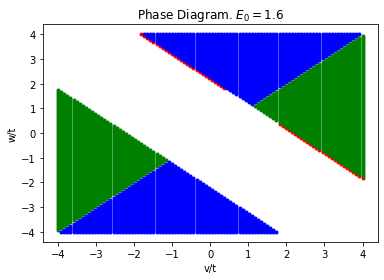

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
for v in np.linspace(-4, 4, 100):
    for w in np.linspace(-4, 4, 100):
        z = winding_number(v,w,1,E0,2,1,1000)
        if (z > -1.1 and z < -0.9):
            ax.plot(v,w,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(v,w,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(v,w,'g.')
        elif(z == 'nan'):
            ax.plot(v,w,'k.')
        else:
            ax.plot(v,w,'r.')
ax.set_title('Phase Diagram. ' + r'$E_0 = {}$'.format(E0))
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.show()

In [ ]:
z = winding_number2(2,-1.1,1,0,2,1,100)
print(z)
#z > -1.1 and z < -0.9

z > 0.9 and z < 1,1
#type(z)

-0.3530373409053889


(False, 1)

<IPython.core.display.Javascript object>


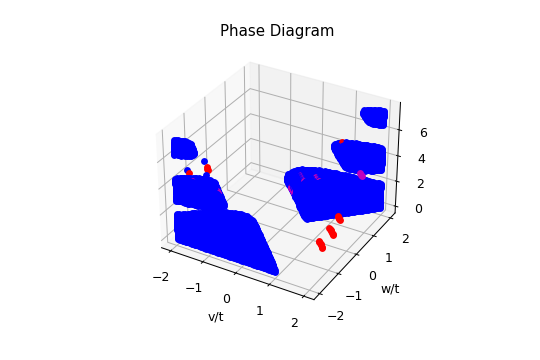

In [ ]:
%matplotlib notebook
fig = plt.figure()
ax = plt.axes(projection='3d')
for A0 in np.linspace(0,8,100):
    for v in np.linspace(-2, 2, 100):
        for w in np.linspace(-2, 2, 100):
            z = winding_number2(v,w,1,A0,2,1,1000)
            if (z > -1.1 and z < -0.9):
                ax.scatter3D(v,w,A0,c='b')
            elif(z > -0.6 and z < -0.4):
                ax.scatter3D(v,w,A0,c ='r')
            elif(z > 0.4 and z < 0.6):
                ax.scatter3D(v,w,A0,c='m')
ax.set_title('Phase Diagram')
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.show()

<IPython.core.display.Javascript object>


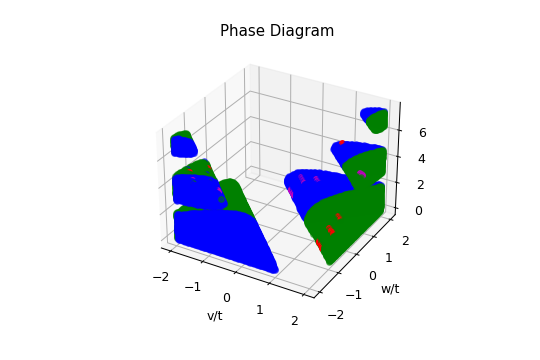

In [ ]:
%matplotlib notebook
fig = plt.figure()
ax = plt.axes(projection='3d')
for A0 in np.linspace(0,8,100):
    for v in np.linspace(-2, 2, 100):
        for w in np.linspace(-2, 2, 100):
            z = winding_number2(v,w,1,A0,2,1,1000)
            if (z > -1.1 and z < -0.9):
                ax.scatter3D(v,w,A0,c='b',alpha=0.5)
            elif(z > 0.9 and z < 1.1):
                ax.scatter3D(v,w,A0,c='g', alpha = 0.5)
            elif(z > -0.6 and z < -0.4):
                ax.scatter3D(v,w,A0,c ='r')
            elif(z > 0.4 and z < 0.6):
                ax.scatter3D(v,w,A0,c='m')
ax.set_title('Phase Diagram')
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.show()

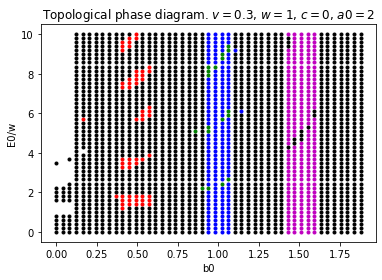

In [ ]:
fig, ax = plt.subplots()
v = 0.3
w = 1
c = 0
a0 = 2
for b0 in np.linspace(0,2,50):
    for A0 in np.linspace(0,10,50):
        z = winding_number(v,w,c,A0,a0,b0,1000)
        if (z > -1.1 and z < -0.9):
            ax.plot(b0,A0,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(b0,A0,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(b0,A0,'g.')
        elif(z > 0.4 and z < 0.6):
            ax.plot(b0,A0,'r.')
        elif(z < -0.4 and z > -0.6):
            ax.plot(b0,A0,'m.')
        else:
            ax.plot(b0,A0,'k.')
ax.set_title('Topological phase diagram. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = {}$'.format(v,w,c,a0))
ax.set(xlabel='b0', ylabel='E0/w')
plt.show()

In [ ]:
v = 0.3
w = 1
c = 0
A0 = 0
a0 = 2
b0 = 1.50
winding_number(v,w,c,A0,a0,b0,1000)

-0.499538461538461

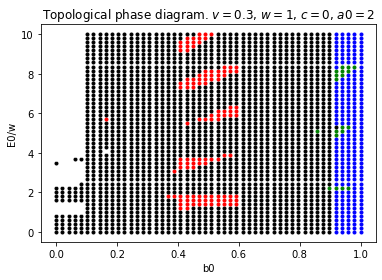

In [ ]:
fig, ax = plt.subplots()
v = 0.3
w = 1
c = 0
a0 = 2
for b0 in np.linspace(0,1,50):
    for A0 in np.linspace(0,10,50):
        z = winding_number(v,w,c,A0,a0,b0,1000)
        if (z > -1.1 and z < -0.9):
            ax.plot(b0,A0,'b.')
        elif (z > -0.1 and z < 0.1):
            ax.plot(b0,A0,'w.')
        elif (z > 0.9 and z < 1.1):
            ax.plot(b0,A0,'g.')
        elif(z > 0.4 and z < 0.6):
            ax.plot(b0,A0,'r.')
        elif(z < -0.4 and z > -0.6):
            ax.plot(b0,A0,'m.')
        else:
            ax.plot(b0,A0,'k.')
        #if (z <0):
            #ax.plot(b0,A0,'.r')
ax.set_title('Topological phase diagram. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = {}$'.format(v,w,c,a0))
ax.set(xlabel='b0', ylabel='E0/w')
plt.show()

In [ ]:
v = 0.3
w = 1
c = 1
A0 = 1
a0 = 1
b0 = 1.5
winding_number(v,w,c,A0,a0,b0,10000)

0.21181892702224597

In [ ]:
v = 0.2
w = 1
c = 1
A0 = 0
a0 = 2
b0 = 1
winding_number(v,w,c,A0,a0,b0,10000)

-1.0002999999999975

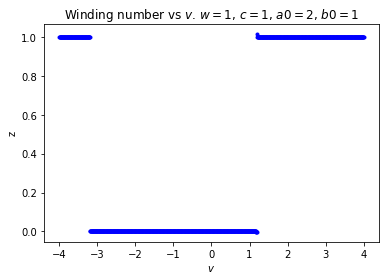

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
w = 1
c = 1
a0 = 2
b0 = 1
for v in np.linspace(-4,4,1000):
  z = winding_number(v,w,1,E0,2,1,10000)
  ax.plot(v,z,'b.')
ax.set_title(r'Winding number vs $v$. ' + r'$w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(w,c,a0, b0))
ax.set(xlabel=r'$v$', ylabel='z')
plt.show()

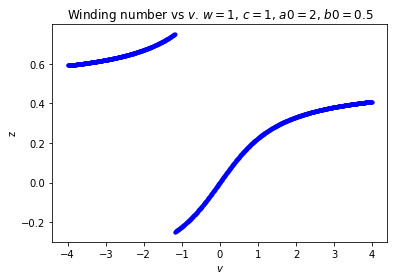

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
w = 1
c = 1
a0 = 2
b0 = 0.5
for v in np.linspace(-4,4,1000):
  z = winding_number(v,w,1,E0,a0,b0,10000)
  ax.plot(v,z,'b.')
ax.set_title(r'Winding number vs $v$. ' + r'$w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(w,c,a0, b0))
ax.set(xlabel=r'$v$', ylabel='z')
plt.show()

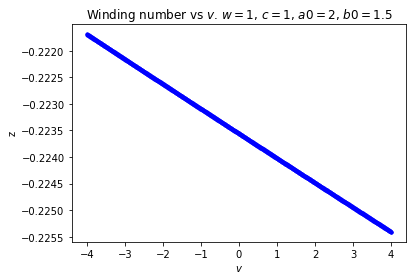

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
w = 1
c = 1
a0 = 2
b0 = 1.5
for v in np.linspace(-4,4,1000):
  z = winding_number(v,w,1,E0,a0,b0,10000)
  ax.plot(v,z,'b.')
ax.set_title(r'Winding number vs $v$. ' + r'$w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(w,c,a0, b0))
ax.set(xlabel=r'$v$', ylabel='z')
plt.show()

In [ ]:
A0 = 1.6
w = 1
c = 1
a0 = 1
b0 = 0.5
v = -4
k = 1

A = A_func(v,A0, a0, b0)
B = B_func(w,A0, a0, b0)

dx_0 = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
dy_0 = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))

dx_2pi = A*np.cos((k+2*np.pi)*b0) + B*np.cos((k+2*np.pi)*(a0-b0)) + c
dy_2pi = A*np.sin((k+2*np.pi)*b0) - B*np.sin((k+2*np.pi)*(a0 - b0))

print(r'$d_x(0) = {}$, $d_x(2 \pi) = {}$'.format(dx_0, dx_2pi))
print(r'$\Delta d_x = {}$'.format(dx_0 - dx_2pi) )
print('')
print(r'$d_y(0) = {}$, $d_y(2 \pi) = {}$'.format(dy_0, dy_2pi))
print(r'$\Delta d_y = {}$'.format(dy_0 - dy_2pi) )

$d_x(0) = -1.2280610693665643$, $d_x(2 \pi) = 3.2280610693665643$
$\Delta d_x = -4.456122138733129$

$d_y(0) = -2.0286588495316202$, $d_y(2 \pi) = 2.02865884953162$
$\Delta d_y = -4.0573176990632405$


In [ ]:
def A_func(v, A0, a0, b0):
    return v*sp.special.jv(0,A0*b0)

def B_func(w, A0, a0, b0):
    return w*sp.special.jv(0,A0*(a0-b0))

def special_winding_number(v, w, c, A0, a0, b0, n):
    a0 = 2*b0
    A = A_func(v,A0, a0, b0)
    B = B_func(w,A0, a0, b0)
    T = (2*np.pi)/b0
    vi = 0
    for k in np.linspace(-T/2, T/2, n):
        P1 = (b0*A*np.cos(k*b0) - (a0-b0)*B*np.cos(k*(a0-b0)))/(B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c)
        P2 = (A*np.sin(k*b0) - B*np.sin(k*(a0-b0)))*(-(a0-b0)*B*np.sin(k*(a0-b0)) - b0*A*np.sin(k*b0))/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
        P3 = np.power((A*np.sin(k*b0) - B*np.sin(k*(a0-b0))),2)/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
        vi += (P1-P2)*(T/n)/(P3+1)
    return vi/(2*np.pi)

In [ ]:
A0 = 1.6
w = 1
c = 1
a0 = 1
b0 = 0.5
v = -4
k = 1

T = (2*np.pi)/b0

A = A_func(v,A0, a0, b0)
B = B_func(w,A0, a0, b0)

dx_0 = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
dy_0 = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))

dx_T = A*np.cos((k+T)*b0) + B*np.cos((k+T)*(a0-b0)) + c
dy_T = A*np.sin((k+T)*b0) - B*np.sin((k+T)*(a0 - b0))

print(r'$d_x(0) = {}$, $d_x(T) = {}$'.format(dx_0, dx_T))
print(r'$\Delta d_x = {}$'.format(dx_0 - dx_T) )
print('')
print(r'$d_y(0) = {}$, $d_y(T) = {}$'.format(dy_0, dy_T))
print(r'$\Delta d_y = {}$'.format(dy_0 - dy_T) )

$d_x(0) = -1.2280610693665643$, $d_x(T) = -1.2280610693665643$
$\Delta d_x = 0.0$

$d_y(0) = -2.0286588495316202$, $d_y(T) = -2.02865884953162$
$\Delta d_y = -4.440892098500626e-16$


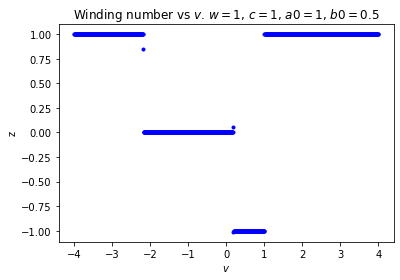

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
w = 1
c = 1
a0 = 1
b0 = 0.5
for v in np.linspace(-4,4,1000):
  z = special_winding_number(v,w,1,E0,a0,b0,10000)
  ax.plot(v,z,'b.')
ax.set_title(r'Winding number vs $v$. ' + r'$w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(w,c,a0, b0))
ax.set(xlabel=r'$v$', ylabel='z')
plt.show()

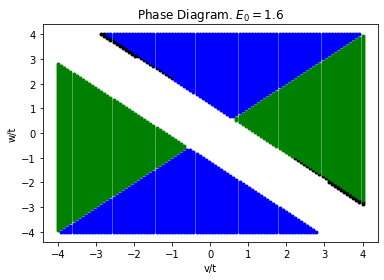

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
a0 = 1
b0 = 0.5
for v in np.linspace(-4, 4, 100):
    for w in np.linspace(-4, 4, 100):
        z = special_winding_number(v,w,1,E0,a0,b0,1000)
        if (z > -1.1 and z < -0.9):
            ax.plot(v,w,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(v,w,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(v,w,'g.')
        elif(z > 0.4 and z < 0.6):
            ax.plot(v,w,'r.')
        elif(z < -0.4 and z > -0.6):
            ax.plot(v,w,'m.')
        else:
            ax.plot(v,w,'k.')
ax.set_title('Phase Diagram. ' + r'$E_0 = {}$'.format(E0))
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.show()

In [ ]:
def A_func(v, A0, a0, b0):
    return v*sp.special.jv(0,A0*b0)

def B_func(w, A0, a0, b0):
    return w*sp.special.jv(0,A0*(a0-b0))

def special_special_winding_number(v, w, c, A0, a0, b0, n):
    A = A_func(v,A0, a0, b0)
    B = B_func(w,A0, a0, b0)
    if(b0 == 0):
      T2 = (2*np.pi)/(a0-b0)
      T = T2
    elif(a0 == 0):
      T1 = (2*np.pi)/b0
      T = T1
    else:
      T1 = (2*np.pi)/b0
      T2 = (2*np.pi)/(a0-b0)
      frac = T1/T2
      factors = frac.as_integer_ratio()
      T = factors[0]*T2
      if(T>10000):
        T = 10000
    vi = 0
    for k in np.linspace(-T/2, T/2, n):
        P1 = (b0*A*np.cos(k*b0) - (a0-b0)*B*np.cos(k*(a0-b0)))/(B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c)
        P2 = (A*np.sin(k*b0) - B*np.sin(k*(a0-b0)))*(-(a0-b0)*B*np.sin(k*(a0-b0)) - b0*A*np.sin(k*b0))/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
        P3 = np.power((A*np.sin(k*b0) - B*np.sin(k*(a0-b0))),2)/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
        vi += (P1-P2)*(T/n)/(P3+1)
    return vi/(2*np.pi)

In [ ]:
A0 = 1.6
w = 1
c = 1
a0 = 5.0/3.0
b0 = 2.0/3.0
v = -4
k = 1

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
T = (T1*T2)/(np.pi)

A = A_func(v,A0, a0, b0)
B = B_func(w,A0, a0, b0)

dx_0 = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
dy_0 = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))

dx_T = A*np.cos((k+T1)*b0) + B*np.cos((k+T)*(a0-b0)) + c
dy_T = A*np.sin((k+T)*b0) - B*np.sin((k+T)*(a0 - b0))

print(r'$d_x(0) = {}$, $d_x(T) = {}$'.format(dx_0, dx_T))
print(r'$\Delta d_x = {}$'.format(dx_0 - dx_T) )
print('')
print(r'$d_y(0) = {}$, $d_y(T) = {}$'.format(dy_0, dy_T))
print(r'$\Delta d_y = {}$'.format(dy_0 - dy_T) )

$d_x(0) = -1.06493993242478$, $d_x(T) = -1.0649399324247808$
$\Delta d_x = 8.881784197001252e-16$

$d_y(0) = -2.201597515780397$, $d_y(T) = -2.2015975157803944$
$\Delta d_y = -2.6645352591003757e-15$


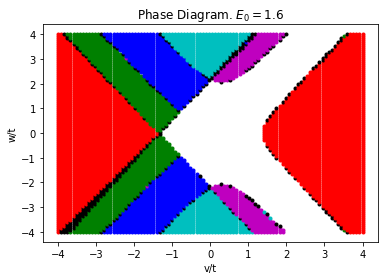

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
a0 = 5.0/3.0
b0 = 2.0/3.0
for v in np.linspace(-4, 4, 100):
    for w in np.linspace(-4, 4, 100):
        z = special_special_winding_number(v,w,1,E0,a0,b0,1000)
        if (z > -1.1 and z < -0.9):
            ax.plot(v,w,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(v,w,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(v,w,'g.')
        elif(z > 1.9 and z < 2.1):
            ax.plot(v,w,'r.')
        elif(z < -1.9 and z > -2.1):
            ax.plot(v,w,'m.')
        elif(z > 2.9 and z < 3.1):
            ax.plot(v,w,'y.')
        elif(z < -2.9 and z > -3.1):
            ax.plot(v,w,'c.')
        else:
            ax.plot(v,w,'k.')
ax.set_title('Phase Diagram. ' + r'$E_0 = {}$'.format(E0))
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.show()

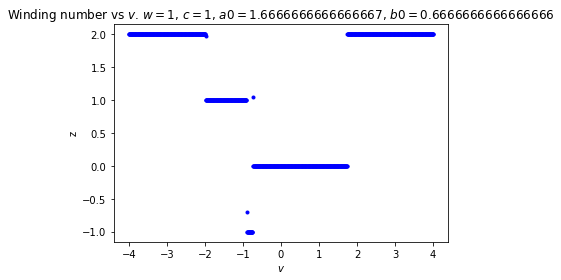

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
w = 1
c = 1
a0 = 5.0/3.0
b0 = 2.0/3.0
for v in np.linspace(-4,4,1000):
  z = special_special_winding_number(v,w,1,E0,a0,b0,10000)
  ax.plot(v,z,'b.')
ax.set_title(r'Winding number vs $v$. ' + r'$w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(w,c,a0, b0))
ax.set(xlabel=r'$v$', ylabel='z')
plt.show()

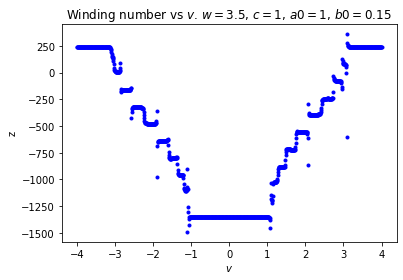

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
w = 3.5
c = 1
a0 = 1
b0 = 0.15
for v in np.linspace(-4,4,1000):
  z = special_special_winding_number(v,w,1,E0,a0,b0,10000)
  ax.plot(v,z,'b.')
ax.set_title(r'Winding number vs $v$. ' + r'$w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(w,c,a0, b0))
ax.set(xlabel=r'$v$', ylabel='z')
plt.show()

In [ ]:
ipa0 = 1
b0 = 0.1
T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
fac = frac.as_integer_ratio()
print(fac)
print(fac[0]*T2)

(9, 1)
62.83185307179586


In [ ]:
special_special_winding_number(-2,1,1,1.6,1,0.15,1000000)

238.75286481931158

In [ ]:
def A_func(v, A0, a0, b0):
    return v*sp.special.jv(0,A0*b0)

def B_func(w, A0, a0, b0):
    return w*sp.special.jv(0,A0*(a0-b0))

def f(k,v,w,c,A0,a0,b0):
    A = A_func(v,A0, a0, b0)
    B = B_func(w,A0, a0, b0)
    P1 = (b0*A*np.cos(k*b0) - (a0-b0)*B*np.cos(k*(a0-b0)))/(B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c)
    P2 = (A*np.sin(k*b0) - B*np.sin(k*(a0-b0)))*(-(a0-b0)*B*np.sin(k*(a0-b0)) - b0*A*np.sin(k*b0))/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
    P3 = np.power((A*np.sin(k*b0) - B*np.sin(k*(a0-b0))),2)/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
    return (P1-P2)/(P3+1)

def super_special_winding_number(v, w, c, A0, a0, b0):
    T1 = (2*np.pi)/b0
    T2 = (2*np.pi)/(a0-b0)
    frac = T1/T2
    factors = frac.as_integer_ratio()
    T = factors[0]*T2
    if(T>1000):
      integral,err = quad(f,-np.inf,np.inf,args=(v,w,c,A0,a0,b0))
    else:
      integral,err = quad(f,-T/2,T/2,args=(v,w,c,A0,a0,b0))
    return integral/(2*np.pi)

In [ ]:
super_special_winding_number(-2,1,1,1.6,1,0.15)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:23: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


-183329.50995227476

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:23: IntegrationWarning: The integral is probably divergent, or slowly convergent.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:23: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:23: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.


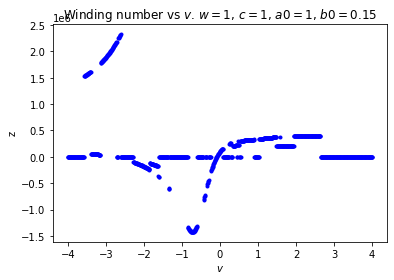

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
w = 1
c = 1
a0 = 1
b0 = 0.15
for v in np.linspace(-4,4,1000):
  z = super_special_winding_number(v,w,1,E0,a0,b0)
  ax.plot(v,z,'b.')
ax.set_title(r'Winding number vs $v$. ' + r'$w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(w,c,a0, b0))
ax.set(xlabel=r'$v$', ylabel='z')
plt.show()

In [ ]:
super_special_winding_number(2,3.5,1,1.6,1,0.15)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:23: IntegrationWarning: The integral is probably divergent, or slowly convergent.


113.87682013366486

In [ ]:
A0 = 1.6
w = 1
c = 1
a0 = 5.0/3.0
b0 = 3.0/2.0
v = -4
k = 1

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2

A = A_func(v,A0, a0, b0)
B = B_func(w,A0, a0, b0)

dx_0 = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
dy_0 = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))

dx_T = A*np.cos((k+T1)*b0) + B*np.cos((k+T)*(a0-b0)) + c
dy_T = A*np.sin((k+T)*b0) - B*np.sin((k+T)*(a0 - b0))

print(r'$d_x(0) = {}$, $d_x(T) = {}$'.format(dx_0, dx_T))
print(r'$\Delta d_x = {}$'.format(dx_0 - dx_T) )
print('')
print(r'$d_y(0) = {}$, $d_y(T) = {}$'.format(dy_0, dy_T))
print(r'$\Delta d_y = {}$'.format(dy_0 - dy_T) )

$d_x(0) = 1.967980014088377$, $d_x(T) = 0.043913685361270605$
$\Delta d_x = 1.9240663287271063$

$d_y(0) = -0.17296555615946135$, $d_y(T) = 0.21905794893397354$
$\Delta d_y = -0.39202350509343487$


3
9.42477796076938


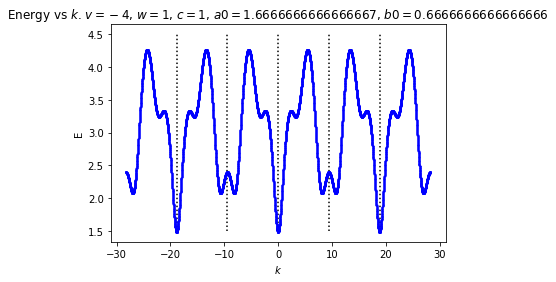

In [ ]:
A0 = 1.6
v = -4
w = 1
c = 1
a0 = 5.0/3.0
b0 = 2.0/3.0

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2/2
print(factors[0])
print(T)

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,A0, a0, b0)
  B = B_func(w,A0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*T, 3*T,10000)

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
ax.vlines(-2*T,1.5,4.5,linestyle='dotted', color = 'black')
ax.vlines(-1*T,1.5,4.5,linestyle='dotted', color = 'black')
ax.vlines(0*T,1.5,4.5,linestyle='dotted', color = 'black')
ax.vlines(1*T,1.5,4.5,linestyle='dotted', color = 'black')
ax.vlines(2*T,1.5,4.5,linestyle='dotted', color = 'black')
ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(v,w,c,a0, b0))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()


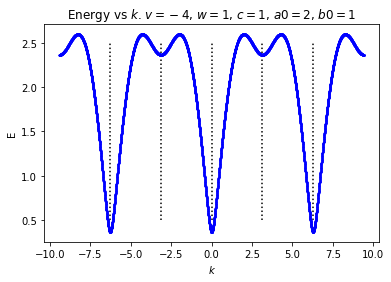

In [ ]:
A0 = 1.6
v = -4
w = 1
c = 1
a0 = 2
b0 = 1

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2/2

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,A0, a0, b0)
  B = B_func(w,A0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*T, 3*T,10000)

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
ax.vlines(-2*T,0.5,2.5,linestyle='dotted', color = 'black')
ax.vlines(-1*T,0.5,2.5,linestyle='dotted', color = 'black')
ax.vlines(0*T,0.5,2.5,linestyle='dotted', color = 'black')
ax.vlines(1*T,0.5,2.5,linestyle='dotted', color = 'black')
ax.vlines(2*T,0.5,2.5,linestyle='dotted', color = 'black')
ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(v,w,c,a0, b0))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()

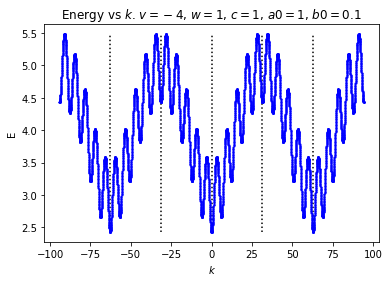

In [ ]:
A0 = 1.6
v = -4
w = 1
c = 1
a0 = 1
b0 = 0.1

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2/2

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,A0, a0, b0)
  B = B_func(w,A0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*T, 3*T,10000)
min_energy = np.amin(Energy(ka,v,w,c,A0,a0,b0))
max_energy = np.amax(Energy(ka,v,w,c,A0,a0,b0))

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
ax.vlines(-2*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(-1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(0*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(2*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(v,w,c,a0, b0))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()

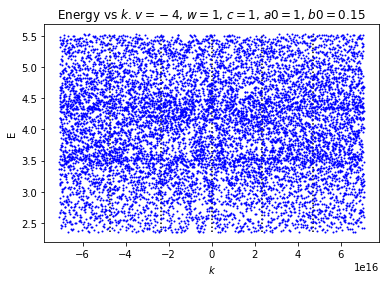

In [ ]:
A0 = 1.6
v = -4
w = 1
c = 1
a0 = 1
b0 = 0.15

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2/2

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,A0, a0, b0)
  B = B_func(w,A0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*T, 3*T,10000)
min_energy = np.amin(Energy(ka,v,w,c,A0,a0,b0))
max_energy = np.amax(Energy(ka,v,w,c,A0,a0,b0))

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
ax.vlines(-2*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(-1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(0*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(2*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(v,w,c,a0, b0))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()

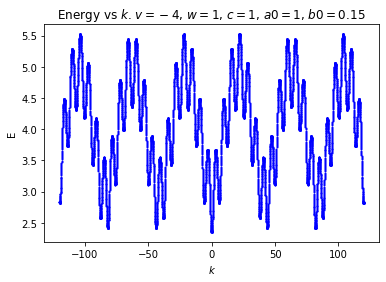

In [ ]:
A0 = 1.6
v = -4
w = 1
c = 1
a0 = 1
b0 = 0.15

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
Ti = factors[0]*T2/2
if Ti>1000:
  Tf = 40
else:
  Tf = Ti

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,A0, a0, b0)
  B = B_func(w,A0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*Tf, 3*Tf,10000)
min_energy = np.amin(Energy(ka,v,w,c,A0,a0,b0))
max_energy = np.amax(Energy(ka,v,w,c,A0,a0,b0))

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
if Ti < 1000:
  ax.vlines(-2*Tf,min_energy,max_energy,linestyle='dotted', color = 'black')
  ax.vlines(-1*Tf,min_energy,max_energy,linestyle='dotted', color = 'black')
  ax.vlines(0*Tf,min_energy,max_energy,linestyle='dotted', color = 'black')
  ax.vlines(1*Tf,min_energy,max_energy,linestyle='dotted', color = 'black')
  ax.vlines(2*Tf,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(v,w,c,a0, b0))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()

In [3]:
def A_func(v, A0, a0, b0):
    return v*sp.special.jv(0,A0*b0)

def B_func(w, A0, a0, b0):
    return w*sp.special.jv(0,A0*(a0-b0))

def f(k,v,w,c,A0,a0,b0):
    A = A_func(v,A0, a0, b0)
    B = B_func(w,A0, a0, b0)
    P1 = (b0*A*np.cos(k*b0) - (a0-b0)*B*np.cos(k*(a0-b0)))/(B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c)
    P2 = (A*np.sin(k*b0) - B*np.sin(k*(a0-b0)))*(-(a0-b0)*B*np.sin(k*(a0-b0)) - b0*A*np.sin(k*b0))/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
    P3 = np.power((A*np.sin(k*b0) - B*np.sin(k*(a0-b0))),2)/np.power((B*np.cos(k*(a0-b0)) + A*np.cos(k*b0) + c),2)
    return (P1-P2)/(P3+1)

def super_special_winding_number2(v, w, c, A0, a0, b0):
  if(b0 == 0):
    T2 = (2*np.pi)/(a0-b0)
    Tf = T2
    integral,err = quad(f,-Tf/2,Tf/2,args=(v,w,c,A0,a0,b0))
  elif(a0 == 0):
    T1 = (2*np.pi)/b0
    Tf = T1
    integral,err = quad(f,-Tf/2,Tf/2,args=(v,w,c,A0,a0,b0))
  else:
    T1 = (2*np.pi)/b0
    T2 = (2*np.pi)/(a0-b0)
    frac = T1/T2
    factors = frac.as_integer_ratio()
    Ti = factors[0]*T2
    if Ti>1000:
      Tf = 40
    else:
      Tf = Ti
    integral,err = quad(f,-Tf/2,Tf/2,args=(v,w,c,A0,a0,b0))
  return integral/(2*np.pi)

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:34: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:34: IntegrationWarning: The integral is probably divergent, or slowly convergent.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:26: RuntimeWarning: divide by zero encountered in double_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:29: RuntimeWarning: invalid value encountered in double_scalars
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:34: IntegrationWarning:

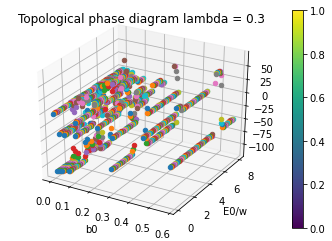

In [ ]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import numpy as np

fig, ax = plt.subplots(subplot_kw={"projection": "3d"})

v = 0.3
w = 1
c = 0
a0 = 1

#b0 = np.linspace(0.00000001,1,100)
#A0 = np.linspace(0,8,100)

for b0 in np.linspace(0,1,1000):
  for A0 in np.linspace(0,8,100):
    if(b0 == 0):
      T2 = (2*np.pi)/(a0-b0)
      Ti = T2
    elif(a0 == 0):
      T1 = (2*np.pi)/b0
      Ti = T1
    else:
      T1 = (2*np.pi)/b0
      T2 = (2*np.pi)/(a0-b0)
      frac = T1/T2
      factors = frac.as_integer_ratio()
      Ti = factors[0]*T2/2
    if Ti>1000:
        pass
    else:
        z = super_special_winding_number2(v,w,c,A0,a0,b0)
        #z = special_special_winding_number(v,w,c,A0,a0,b0,1000)
        #ax.scatter3D(b0, A0, z, c=z, cmap='coolwarm')
        a = ax.scatter3D(b0, A0, z, cmap=cm.coolwarm, antialiased=False)
ax.set_title('Topological phase diagram lambda = 0.3')
ax.set(xlabel='b0', ylabel='E0/w')
#ax.view_init(90, -90)
plt.colorbar(a)
plt.show()

In [ ]:
v = 0.3
w = 1
c = 1
A0 = 0
a0 = 1
b0 = 0.1
if(b0 != 0 and a0 != 0):
  T1 = (2*np.pi)/b0
  T2 = (2*np.pi)/(a0-b0)
  frac = T1/T2
  fac = frac.as_integer_ratio()
  print(fac)
  print(fac[0]*T2)
a1 =super_special_winding_number2(v,w,c,A0,a0,b0)
print(a1)
a2 = special_special_winding_number(v,w,c,A0,a0,b0,10000)
print(a2)

(9, 1)
62.83185307179586
-3.0905518754464367


/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:34: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


-2.952481952955084


<IPython.core.display.Javascript object>


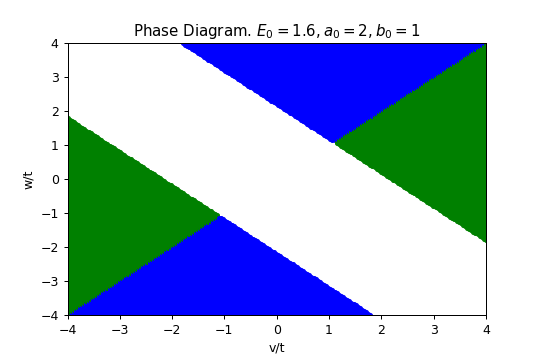

In [ ]:
%matplotlib notebook
fig, ax = plt.subplots()
E0 = 1.6
a0 = 2
b0 = 1
for v in np.linspace(-4, 4, 200):
    for w in np.linspace(-4, 4, 200):
        z = super_special_winding_number2(v,w,1,E0,a0,b0)
        if (z > -1.1 and z < -0.9):
            ax.plot(v,w,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(v,w,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(v,w,'g.')
        elif(z > 1.9 and z < 2.1):
            ax.plot(v,w,'r.')
        elif(z < -1.9 and z > -2.1):
            ax.plot(v,w,'m.')
        elif(z > 2.9 and z < 3.1):
            ax.plot(v,w,'y.')
        elif(z < -2.9 and z > -3.1):
            ax.plot(v,w,'c.')
        else:
            ax.plot(v,w,'k.')
ax.set_title('Phase Diagram. ' + r'$E_0 = {}, a_0 = {}, b_0 = {}$'.format(E0, a0, b0))
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.show()

<IPython.core.display.Javascript object>


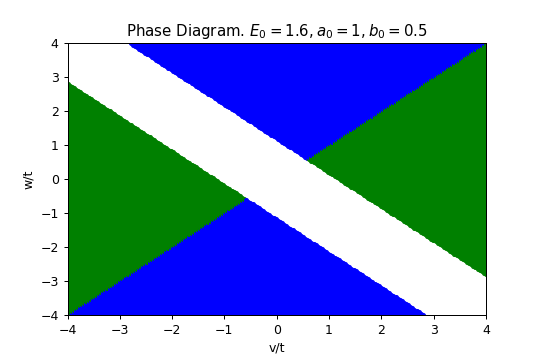

In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
a0 = 1
b0 = 0.5
for v in np.linspace(-4, 4, 200):
    for w in np.linspace(-4, 4, 200):
        z = super_special_winding_number2(v,w,1,E0,a0,b0)
        if (z > -1.1 and z < -0.9):
            ax.plot(v,w,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(v,w,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(v,w,'g.')
        elif(z > 1.9 and z < 2.1):
            ax.plot(v,w,'r.')
        elif(z < -1.9 and z > -2.1):
            ax.plot(v,w,'m.')
        elif(z > 2.9 and z < 3.1):
            ax.plot(v,w,'y.')
        elif(z < -2.9 and z > -3.1):
            ax.plot(v,w,'c.')
        else:
            ax.plot(v,w,'k.')
ax.set_title('Phase Diagram. ' + r'$E_0 = {}, a_0 = {}, b_0 = {}$'.format(E0, a0, b0))
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.show()

<IPython.core.display.Javascript object>


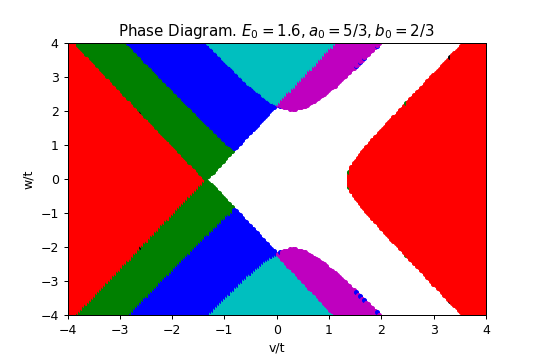

C:\Users\scien\AppData\Local\Temp\ipykernel_19372\1375462404.py:34: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral,err = quad(f,-Tf/2,Tf/2,args=(v,w,c,A0,a0,b0))
C:\Users\scien\AppData\Local\Temp\ipykernel_19372\1375462404.py:34: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral,err = quad(f,-Tf/2,Tf/2,args=(v,w,c,A0,a0,b0))


In [ ]:
fig, ax = plt.subplots()
E0 = 1.6
a0 = 5.0/3.0
b0 = 2.0/3.0
for v in np.linspace(-4, 4, 200):
    for w in np.linspace(-4, 4, 200):
        z = super_special_winding_number2(v,w,1,E0,a0,b0)
        if (z > -1.1 and z < -0.9):
            ax.plot(v,w,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(v,w,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(v,w,'g.')
        elif(z > 1.9 and z < 2.1):
            ax.plot(v,w,'r.')
        elif(z < -1.9 and z > -2.1):
            ax.plot(v,w,'m.')
        elif(z > 2.9 and z < 3.1):
            ax.plot(v,w,'y.')
        elif(z < -2.9 and z > -3.1):
            ax.plot(v,w,'c.')
        else:
            ax.plot(v,w,'k.')
ax.set_title('Phase Diagram. ' + r'$E_0 = {}, a_0 = 5/3, b_0 = 2/3$'.format(E0, a0, b0))
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.show()

<ipython-input-3-542a263b7199>:34: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral,err = quad(f,-Tf/2,Tf/2,args=(v,w,c,A0,a0,b0))
<ipython-input-3-542a263b7199>:34: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  integral,err = quad(f,-Tf/2,Tf/2,args=(v,w,c,A0,a0,b0))


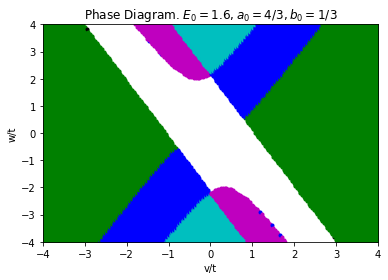

In [8]:
fig, ax = plt.subplots()
E0 = 1.6
a0 = 4.0/3.0
b0 = 1.0/3.0
for v in np.linspace(-4, 4, 200):
    for w in np.linspace(-4, 4, 200):
        z = super_special_winding_number2(v,w,1,E0,a0,b0)
        if (z > -1.1 and z < -0.9):
            ax.plot(v,w,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(v,w,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(v,w,'g.')
        elif(z > 1.9 and z < 2.1):
            ax.plot(v,w,'r.')
        elif(z < -1.9 and z > -2.1):
            ax.plot(v,w,'m.')
        elif(z > 2.9 and z < 3.1):
            ax.plot(v,w,'y.')
        elif(z < -2.9 and z > -3.1):
            ax.plot(v,w,'c.')
        else:
            ax.plot(v,w,'k.')
ax.set_title('Phase Diagram. ' + r'$E_0 = {}, a_0 = 4/3, b_0 = 1/3$'.format(E0, a0, b0))
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.show()

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def multiple_formatter(denominator=2, number=np.pi, latex='\pi'):
    def gcd(a, b):
        while b:
            a, b = b, a%b
        return a
    def _multiple_formatter(x, pos):
        den = denominator
        num = np.int(np.rint(den*x/number))
        com = gcd(num,den)
        (num,den) = (int(num/com),int(den/com))
        if den==1:
            if num==0:
                return r'$0$'
            if num==1:
                return r'$%s$'%latex
            elif num==-1:
                return r'$-%s$'%latex
            else:
                return r'$%s%s$'%(num,latex)
        else:
            if num==1:
                return r'$\frac{%s}{%s}$'%(latex,den)
            elif num==-1:
                return r'$\frac{-%s}{%s}$'%(latex,den)
            else:
                return r'$\frac{%s%s}{%s}$'%(num,latex,den)
    return _multiple_formatter

class Multiple:
    def __init__(self, denominator=2, number=np.pi, latex='\pi'):
        self.denominator = denominator
        self.number = number
        self.latex = latex

    def locator(self):
        return plt.MultipleLocator(self.number / self.denominator)

    def formatter(self):
        return plt.FuncFormatter(multiple_formatter(self.denominator, self.number, self.latex))

C:\Users\scien\AppData\Local\Temp\ipykernel_9912\402784350.py:11: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num = np.int(np.rint(den*x/number))


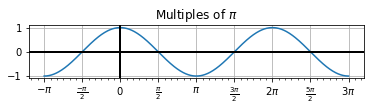

In [ ]:
x = np.linspace(-np.pi, 3*np.pi,500)
plt.plot(x, np.cos(x))
plt.title(r'Multiples of $\pi$')
ax = plt.gca()
ax.grid(True)
ax.set_aspect(1.0)
ax.axhline(0, color='black', lw=2)
ax.axvline(0, color='black', lw=2)
ax.xaxis.set_major_locator(plt.MultipleLocator(np.pi / 2))
ax.xaxis.set_minor_locator(plt.MultipleLocator(np.pi / 12))
ax.xaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))
plt.show()

C:\Users\scien\AppData\Local\Temp\ipykernel_9912\402784350.py:11: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num = np.int(np.rint(den*x/number))


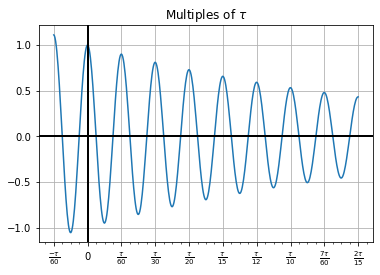

In [ ]:
tau = np.pi*2
den = 60
major = Multiple(den, tau, r'\tau')
minor = Multiple(den*4, tau, r'\tau')
x = np.linspace(-tau/60, tau*8/60,500)
plt.plot(x, np.exp(-x)*np.cos(60*x))
plt.title(r'Multiples of $\tau$')
ax = plt.gca()
ax.grid(True)
ax.axhline(0, color='black', lw=2)
ax.axvline(0, color='black', lw=2)
ax.xaxis.set_major_locator(major.locator())
ax.xaxis.set_minor_locator(minor.locator())
ax.xaxis.set_major_formatter(major.formatter())
plt.show()

<IPython.core.display.Javascript object>


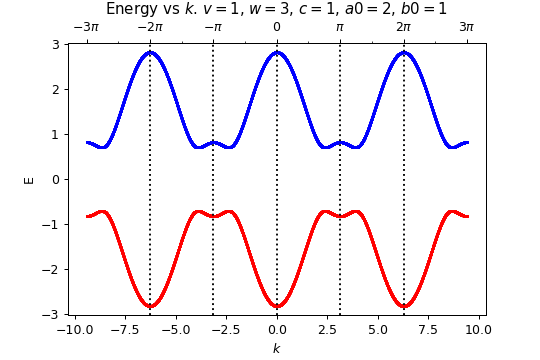

In [ ]:
A0 = 1.6
v = 1
w = 3
c = 1
a0 = 2
b0 = 1

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2/2

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,E0, a0, b0)
  B = B_func(w,E0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*T, 3*T,10000)
min_energy = np.amin(-Energy(ka,v,w,c,A0,a0,b0)) - 0.2
max_energy = np.amax(Energy(ka,v,w,c,A0,a0,b0)) + 0.2

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
ax.plot(ka,-Energy(ka,v,w,c,A0,a0,b0),'r.', markersize = 2)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
#ax2.set_xticks(new_tick_locations)
#ax2.set_xticklabels(tick_function(new_tick_locations))
ax2.xaxis.set_major_locator(plt.MultipleLocator(np.pi / 1))
ax2.xaxis.set_minor_locator(plt.MultipleLocator(np.pi / 2))
ax2.xaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))

ax.vlines(-2*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(-1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(0*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(2*T,min_energy,max_energy,linestyle='dotted', color = 'black')

plt.ylim(min_energy, max_energy)

ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(v,w,c,a0, b0))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()

<ipython-input-4-a88b1269bb25>:11: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num = np.int(np.rint(den*x/number))


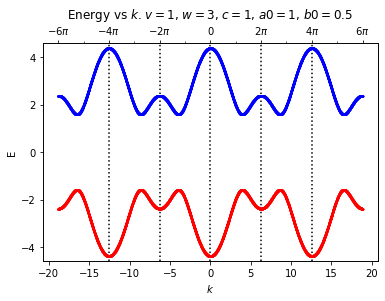

In [ ]:
A0 = 1.6
v = 1
w = 3
c = 1
a0 = 1
b0 = 0.5

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2/2

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,E0, a0, b0)
  B = B_func(w,E0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*T, 3*T,10000)
min_energy = np.amin(-Energy(ka,v,w,c,A0,a0,b0)) - 0.2
max_energy = np.amax(Energy(ka,v,w,c,A0,a0,b0)) + 0.2

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
ax.plot(ka,-Energy(ka,v,w,c,A0,a0,b0),'r.', markersize = 2)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
#ax2.set_xticks(new_tick_locations)
#ax2.set_xticklabels(tick_function(new_tick_locations))
ax2.xaxis.set_major_locator(plt.MultipleLocator(np.pi / 0.5))
ax2.xaxis.set_minor_locator(plt.MultipleLocator(np.pi / 1))
ax2.xaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))

ax.vlines(-2*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(-1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(0*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(2*T,min_energy,max_energy,linestyle='dotted', color = 'black')

plt.ylim(min_energy, max_energy)

ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = {}$, $b0 = {}$'.format(v,w,c,a0, b0))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()

<ipython-input-4-a88b1269bb25>:11: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num = np.int(np.rint(den*x/number))


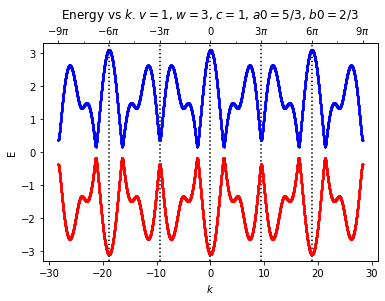

In [ ]:
A0 = 1.6
v = 1
w = 3
c = 1
a0 = 5.0/3.0
b0 = 2.0/3.0

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2/2

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,E0, a0, b0)
  B = B_func(w,E0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*T, 3*T,10000)
min_energy = np.amin(-Energy(ka,v,w,c,A0,a0,b0)) - 0.2
max_energy = np.amax(Energy(ka,v,w,c,A0,a0,b0)) + 0.2

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
ax.plot(ka,-Energy(ka,v,w,c,A0,a0,b0),'r.', markersize = 2)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
#ax2.set_xticks(new_tick_locations)
#ax2.set_xticklabels(tick_function(new_tick_locations))
ax2.xaxis.set_major_locator(plt.MultipleLocator(np.pi *3))
ax2.xaxis.set_minor_locator(plt.MultipleLocator(np.pi *1.5))
ax2.xaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))

ax.vlines(-2*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(-1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(0*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(2*T,min_energy,max_energy,linestyle='dotted', color = 'black')

plt.ylim(min_energy, max_energy)

ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = 5/3$, $b0 = 2/3$'.format(v,w,c))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()

<ipython-input-5-a88b1269bb25>:11: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  num = np.int(np.rint(den*x/number))


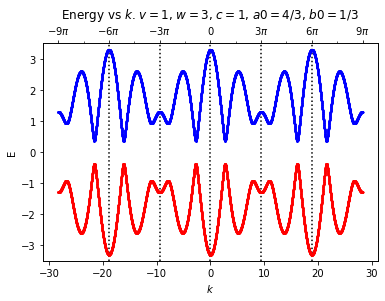

In [6]:
A0 = 1.6
v = 1
w = 3
c = 1
a0 = 4.0/3.0
b0 = 1.0/3.0

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2/2

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,E0, a0, b0)
  B = B_func(w,E0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*T, 3*T,10000)
min_energy = np.amin(-Energy(ka,v,w,c,A0,a0,b0)) - 0.2
max_energy = np.amax(Energy(ka,v,w,c,A0,a0,b0)) + 0.2

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
ax.plot(ka,-Energy(ka,v,w,c,A0,a0,b0),'r.', markersize = 2)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
#ax2.set_xticks(new_tick_locations)
#ax2.set_xticklabels(tick_function(new_tick_locations))
ax2.xaxis.set_major_locator(plt.MultipleLocator(np.pi *3))
ax2.xaxis.set_minor_locator(plt.MultipleLocator(np.pi *1.5))
ax2.xaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))

ax.vlines(-2*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(-1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(0*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(2*T,min_energy,max_energy,linestyle='dotted', color = 'black')

plt.ylim(min_energy, max_energy)

ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = 4/3$, $b0 = 1/3$'.format(v,w,c))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()

In [13]:
sigma_x = np.array(((0, 1), (1, 0)))
sigma_y = np.array(((0, -1j),(1j,0)))

In [12]:
def mask_c1(N):
    H = np.zeros((2*N,2*N),dtype=complex)
    for n in range(0,N):
        for m in range(0,N):
            if(n == m):
                H[(n*2):(n*2)+2,(m*2):(m*2)+2] = 1*(sigma_x +1j*sigma_y)/2
    return H

def mask_c2(N):
    H = np.zeros((2*N,2*N),dtype=complex)
    for n in range(0,N):
        for m in range(0,N):
            if(n == m):
                H[(n*2):(n*2)+2,(m*2):(m*2)+2] = 1*(sigma_x -1j*sigma_y)/2
    return H

def mask_w1(N):
    H = np.zeros((2*N,2*N),dtype=complex)
    for n in range(0,N):
        for m in range(0,N):
            if(n + 1 == m):
                H[(n*2):(n*2)+2,(m*2):(m*2)+2] = 1*(sigma_x -1j*sigma_y)/2
    return H

def mask_w2(N):
    H = np.zeros((2*N,2*N),dtype=complex)
    for n in range(0,N):
        for m in range(0,N):
            if(n == m + 1):
                H[(n*2):(n*2)+2,(m*2):(m*2)+2] = 1*(sigma_x +1j*sigma_y)/2
    return H
def mask_v1(N):
    H = np.zeros((2*N,2*N),dtype=complex)
    for n in range(0,N):
        for m in range(0,N):
            if(n + 1 == m):
                H[(n*2):(n*2)+2,(m*2):(m*2)+2] = 1*(sigma_x +1j*sigma_y)/2
    return H

def mask_v2(N):
    H = np.zeros((2*N,2*N),dtype=complex)
    for n in range(0,N):
        for m in range(0,N):
            if(n == m + 1):
                H[(n*2):(n*2)+2,(m*2):(m*2)+2] = 1*(sigma_x -1j*sigma_y)/2
    return H

In [10]:
# PLOT LI Energy vs v
def plot_Li_position(N,h,om,win,tout,emax, a0, b0,vi,vf,tipo):
    fig, ax = plt.subplots()
    #N=20
    d=h
    mc1 = mask_c1(N)
    mc2 = mask_c2(N)
    mv1 = mask_v1(N)
    mv2 = mask_v2(N)
    mw1 = mask_w1(N)
    mw2 = mask_w2(N)
    A0 = emax
    #b0 = 1
    #a0 = 2
    for vout in np.linspace(vi,vf,100):
        if(tipo == 1):
            wout = win
        elif(tipo == 2):
            wout = -2*vout + 2
        elif(tipo == 3):
            wout = vout + 1
        elif(tipo == 4):
            wout = vout
        elif(tipo == 5):
            wout = 2 - vout
        elif(tipo == 6):
            wout = - vout
        omega = om
        for n in range(-d,d+1):
            for m in range(-d,d+1):
                Av = vout*sp.special.jv(n-m,A0*b0)
                Avc = vout*sp.special.jv(m-n,A0*b0)
                Bw = wout*sp.special.jv(m-n,A0*(a0-b0))
                Bwc = wout*sp.special.jv(n-m,A0*(a0-b0))
                v1 = Av
                w1 = Bwc
                v2 = Avc
                w2 = Bw
                #H = np.zeros((2*N,2*N),dtype=complex)
                H = w1*mw1 + w2*mw2 + v1*mv1 + v2*mv2
                if(n == m):
                    H += n*omega*np.eye(2*N)
                    H += mc1*tout + mc2*tout

                if (n== m):
                    globals()["H"+str(n)] = H
                else:
                    globals()["J"+str(n)+str(m)] = H
                    
        Hfinal2 = np.zeros(((2*d + 1)*2*N,(2*d + 1)*2*N),dtype=complex)
        for n in range(-d,d+1):
            for m in range(-d,d+1):
                if(m==n):
                    Hfinal2[2*N*(n+d):2*N*(n+d)+2*N,2*N*(m+d):2*N*(m+d) +2*N] = globals()["H"+str(n)]
                else:
                    Hfinal2[2*N*(n+d):2*N*(n+d)+2*N,2*N*(m+d):2*N*(m+d) +2*N] = globals()["J"+str(n)+str(m)]

        #eigenvalues0, eigenvectors0 = eigsh(globals()["H"+str(0)], k=2*N, which='SM')
        #eigenvalues0, eigenvectors0 = eigsh(globals()["H"+str(d+1)], k=2*N, which='SM')
        #epsilon0 = eigenvalues0 * np.eye(2*N)
        
        #epsilon0 = globals()["H"+str(0)]
        
        #Hfinal = new_floquet_recursion((2*d)+1,epsilon0)    

        #eigenvalues, eigenvectors = eigsh(Hfinal2, k=(2*d + 1)*2*N, which='SM')
        #for g in range(0,(2*d + 1)*2*N):
        eigenvalues, eigenvectors = eigsh(Hfinal2, k=2*N, which='SM')
        for g in range(0,2*N):
            ax.plot(vout,eigenvalues[g],'b.',markersize = 0.5)
    ax.set_title('Numerical solution '+ str(N) +' dimers coordinate space n = m = '+ str(d) +r', $w$ = ' + str(wout))
    ax.set(xlabel='v', ylabel='Quasi-Energy')
    plt.xlim(-4,4)
    plt.show()
    return

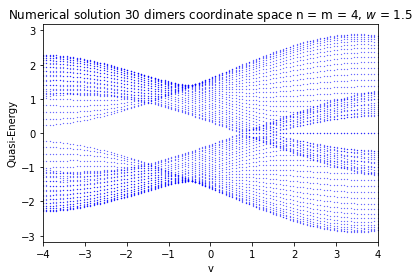

In [14]:
N=30
h = 4
om = 10
wout = 1.5
tout = 1
A0 = 1.6
a0 = 2
b0 = 1
vi = -4
vf = 4
plot_Li_position(N,h,om,wout,tout,A0, a0, b0, vi, vf,1)

<IPython.core.display.Javascript object>


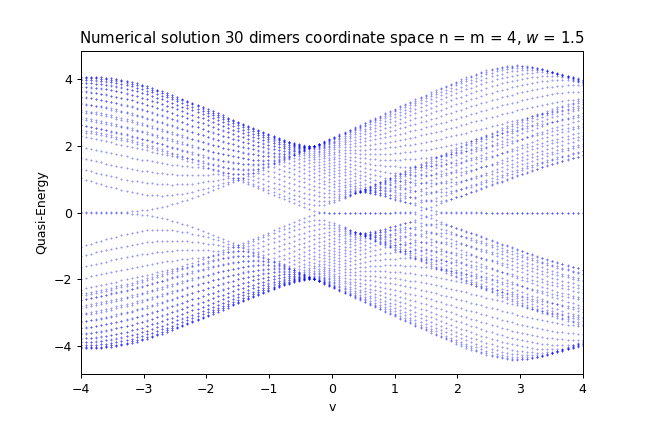

In [ ]:
N=30
h = 4
om = 10
wout = 1.5
tout = 1
A0 = 1.6
a0 = 1
b0 = 0.5
vi = -4
vf = 4
plot_Li_position(N,h,om,wout,tout,A0, a0, b0, vi, vf,1)

<IPython.core.display.Javascript object>


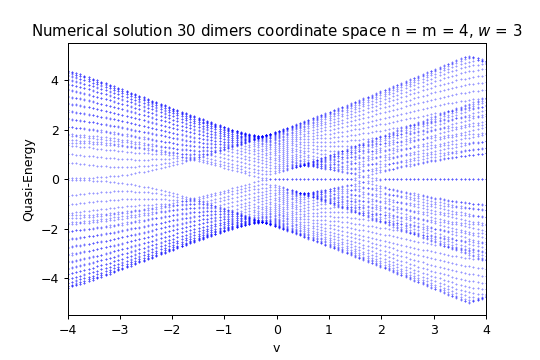

In [ ]:
N=30
h = 4
om = 10
w = 3
tout = 1
A0 = 1.6
a0 = 5.0/3.0
b0 = 2.0/3.0
vi = -4
vf = 4
plot_Li_position(N,h,om,w,tout,A0, a0, b0, vi, vf,1)

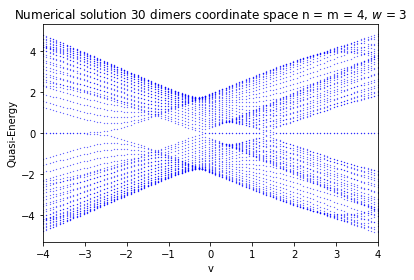

In [15]:
N=30
h = 4
om = 10
w = 3
tout = 1
A0 = 1.6
a0 = 4.0/3.0
b0 = 1.0/3.0
vi = -4
vf = 4
plot_Li_position(N,h,om,w,tout,A0, a0, b0, vi, vf,1)

In [ ]:
mask_w2(3)

array([[0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 1.+0.j, 0.+0.j, 0.+0.j],
       [0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j]])

<IPython.core.display.Javascript object>


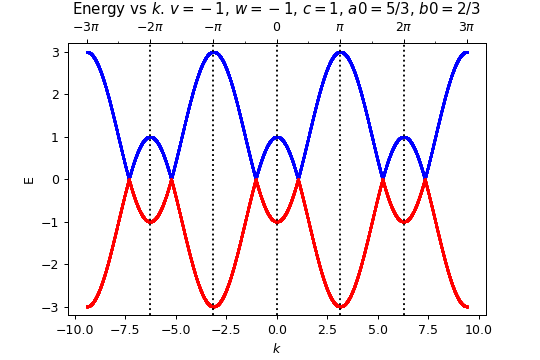

In [ ]:
A0 = 0
v = -1
w = -1
c = 1
a0 = 2
b0 = 1

T1 = (2*np.pi)/b0
T2 = (2*np.pi)/(a0-b0)
frac = T1/T2
factors = frac.as_integer_ratio()
T = factors[0]*T2/2

def Energy(k,v,w,c,E0,a0,b0):
  A = A_func(v,E0, a0, b0)
  B = B_func(w,E0, a0, b0)
  equis = A*np.cos(k*b0) + B*np.cos(k*(a0-b0)) + c
  ye = A*np.sin(k*b0) - B*np.sin(k*(a0 - b0))
  return np.sqrt(np.power(equis,2) + np.power(ye,2))

ka = np.linspace(-3*T, 3*T,10000)
min_energy = np.amin(-Energy(ka,v,w,c,A0,a0,b0)) - 0.2
max_energy = np.amax(Energy(ka,v,w,c,A0,a0,b0)) + 0.2

fig, ax = plt.subplots()
ax.plot(ka,Energy(ka,v,w,c,A0,a0,b0),'b.', markersize = 2)
ax.plot(ka,-Energy(ka,v,w,c,A0,a0,b0),'r.', markersize = 2)

ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
#ax2.set_xticks(new_tick_locations)
#ax2.set_xticklabels(tick_function(new_tick_locations))
ax2.xaxis.set_major_locator(plt.MultipleLocator(np.pi *1))
ax2.xaxis.set_minor_locator(plt.MultipleLocator(np.pi *0.5))
ax2.xaxis.set_major_formatter(plt.FuncFormatter(multiple_formatter()))

ax.vlines(-2*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(-1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(0*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(1*T,min_energy,max_energy,linestyle='dotted', color = 'black')
ax.vlines(2*T,min_energy,max_energy,linestyle='dotted', color = 'black')

plt.ylim(min_energy, max_energy)

ax.set_title(r'Energy vs $k$. ' + r'$v = {}$, $w = {}$, $c = {}$, $a0 = 5/3$, $b0 = 2/3$'.format(v,w,c))
ax.set(xlabel=r'$k$', ylabel='E')
plt.show()

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:34: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:34: IntegrationWarning: The integral is probably divergent, or slowly convergent.


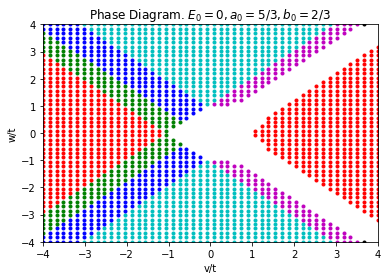

In [ ]:
fig, ax = plt.subplots()
E0 = 0
a0 = 5.0/3.0
b0 = 2.0/3.0
for v in np.linspace(-4, 4, 50):
    for w in np.linspace(-4, 4, 50):
        z = super_special_winding_number2(v,w,1,E0,a0,b0)
        if (z > -1.1 and z < -0.9):
            ax.plot(v,w,'b.')
        elif (z > -0.1 and z < 0.1):
            #ax.plot(v,w,'w.')
            pass
        elif (z > 0.9 and z < 1.1):
            ax.plot(v,w,'g.')
        elif(z > 1.9 and z < 2.1):
            ax.plot(v,w,'r.')
        elif(z < -1.9 and z > -2.1):
            ax.plot(v,w,'m.')
        elif(z > 2.9 and z < 3.1):
            ax.plot(v,w,'y.')
        elif(z < -2.9 and z > -3.1):
            ax.plot(v,w,'c.')
        else:
            ax.plot(v,w,'k.')
ax.set_title('Phase Diagram. ' + r'$E_0 = {}, a_0 = 5/3, b_0 = 2/3$'.format(E0, a0, b0))
ax.set(xlabel = 'v/t', ylabel = 'w/t')
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.show()

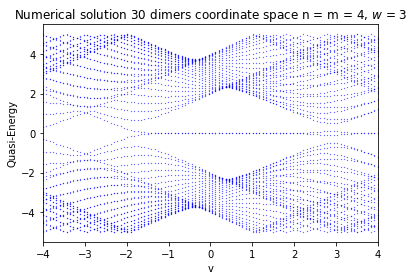

In [ ]:
N=30
h = 4
om = 10
w = 3
tout = 1
A0 = 0
a0 = 5.0/3.0
b0 = 2.0/3.0
vi = -4
vf = 4
plot_Li_position(N,h,om,w,tout,A0, a0, b0, vi, vf,1)